In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()

### Bisection Algorithm

The bisection algorithm is a simple method for finding the roots of one-dimensional functions. The goal is to find a root $x_0\in[a, b]$ such that $f(x_0)=0$. The algorithm starts with a large interval, known to contain $x_0$, and then successively reduces the size of the interval until it brackets the root. The theoretical underpinning of the algorithm is the [intermediate value theorem](https://en.wikipedia.org/wiki/Intermediate_value_theorem) which states that if a continuous function $f$ takes values $f(a)$ and $f(b)$ at the end points of the interval $[a, b]$, then $f$ must take all values between $f(a)$ and $f(b)$ somewhere in the interval. So if $f(a) < \gamma < f(b)$, then there exists a $c\in[a, b]$ such that $f(c)=\gamma$.

Using this information, we can present the bisection algorithm. First we must check that $\text{sign}(f(a)) \ne \text{sign}(f(b))$. Otherwise, the interval does not contain the root and might need to be widened. Then we can proceed:

1. Let $c = \frac{a + b}{2}$.
2. If $f(c) = 0$, stop and return $c$.
3. If $\text{sign}(f(a))\ne\text{sign}(f(c))$, then set $b\leftarrow c$. Else if $\text{sign}(f(b))\ne\text{sign}(f(c))$, then set $a\leftarrow c$.
4. Goto the beginning and repeat until convergence (see below).

After $n$ iterations, the size of the interval bracketing the root will be $2^{-n}(b-a)$.

The bisection algorithm is useful, conceptually simple, and is easy to implement. In particular, you do not need any special information about the function $f$ except the ability to evaluate it at various points in the interval. The downsides are that it is only useful in one dimension and its convergence is linear, which is the slowest rate of convergence for algorithms we will discuss (more on that later).

The bisection algorithm can run into problems in situations where the function $f$ is not well behaved. The ideal situation for the bisection algorithm looks something like this.

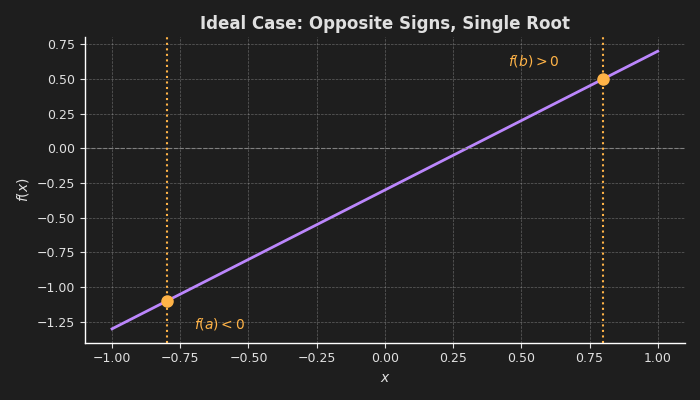

In [2]:
x = np.linspace(-1, 1, 500)
f_ideal = lambda x: x - 0.3

a, b = -0.8, 0.8
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, f_ideal(x), color=C['purple'], lw=2)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(a, color=C['orange'], lw=1.5, ls=':')
ax.axvline(b, color=C['orange'], lw=1.5, ls=':')
ax.plot([a, b], [f_ideal(a), f_ideal(b)], 'o', color=C['orange'], ms=8)
ax.annotate('$f(a)<0$', xy=(a, f_ideal(a)), xytext=(a+0.1, f_ideal(a)-0.2),
            color=C['orange'], fontsize=10)
ax.annotate('$f(b)>0$', xy=(b, f_ideal(b)), xytext=(b-0.35, f_ideal(b)+0.1),
            color=C['orange'], fontsize=10)
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Ideal Case: Opposite Signs, Single Root')
plt.tight_layout()



Here, $f(a)$ and $f(b)$ are of opposite signs and the root is clearly in between $a$ and $b$.

In the scenario below, the algorithm will not start because $f(a)>0$ and $f(b)>0$. A root does in fact exist here, but $f$ is tangent to zero at that point -- the derivative of $f$ at the root is $0$ -- so there is no sign change for the algorithm to detect.

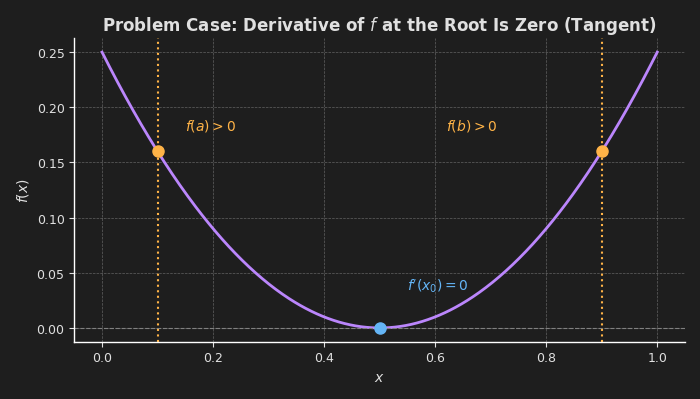

In [3]:
x = np.linspace(0, 1, 500)
f_tan = lambda x: (x - 0.5)**2

a, b = 0.1, 0.9
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, f_tan(x), color=C['purple'], lw=2)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(a, color=C['orange'], lw=1.5, ls=':')
ax.axvline(b, color=C['orange'], lw=1.5, ls=':')
ax.plot([a, b], [f_tan(a), f_tan(b)], 'o', color=C['orange'], ms=8)
ax.plot([0.5], [0.0], 'o', color=C['blue'], ms=8)
ax.annotate('$f(a)>0$', xy=(a, f_tan(a)), xytext=(a+0.05, f_tan(a)+0.02),
            color=C['orange'], fontsize=10)
ax.annotate('$f(b)>0$', xy=(b, f_tan(b)), xytext=(b-0.28, f_tan(b)+0.02),
            color=C['orange'], fontsize=10)
ax.annotate("$f'(x_0)=0$", xy=(0.5, 0.0), xytext=(0.55, 0.035),
            color=C['blue'], fontsize=10)
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Problem Case: Derivative of $f$ at the Root Is Zero (Tangent)')
plt.tight_layout()



In this next scenario, there are two roots between $a$ and $b$, in addition to having $f(a)>0$ and $f(b)>0$. One would need to reduce the length of the starting interval in order to find either root.

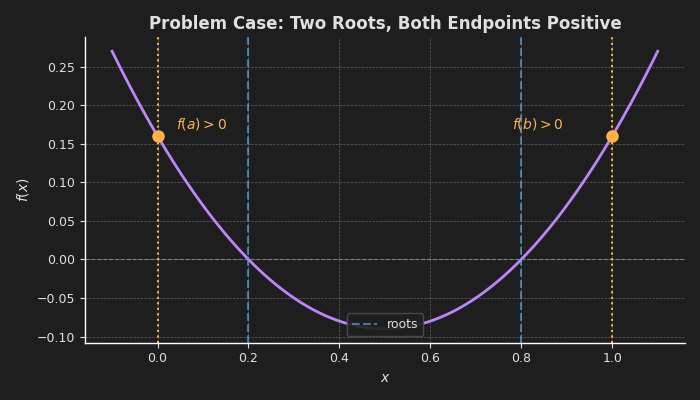

In [4]:
x = np.linspace(-0.1, 1.1, 500)
f_two = lambda x: (x - 0.2) * (x - 0.8)

a, b = 0.0, 1.0
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, f_two(x), color=C['purple'], lw=2)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(a, color=C['orange'], lw=1.5, ls=':')
ax.axvline(b, color=C['orange'], lw=1.5, ls=':')
ax.axvline(0.2, color=C['blue'], lw=1.5, ls='--', alpha=0.6, label='roots')
ax.axvline(0.8, color=C['blue'], lw=1.5, ls='--', alpha=0.6)
ax.plot([a, b], [f_two(a), f_two(b)], 'o', color=C['orange'], ms=8)
ax.annotate('$f(a)>0$', xy=(a, f_two(a)), xytext=(a+0.04, f_two(a)+0.01),
            color=C['orange'], fontsize=10)
ax.annotate('$f(b)>0$', xy=(b, f_two(b)), xytext=(b-0.22, f_two(b)+0.01),
            color=C['orange'], fontsize=10)
ax.legend(loc='lower center')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Problem Case: Two Roots, Both Endpoints Positive')
plt.tight_layout()



In the scenario below, the algorithm will start because $f(a)$ and $f(b)$ are of opposite sign, but there is no root.

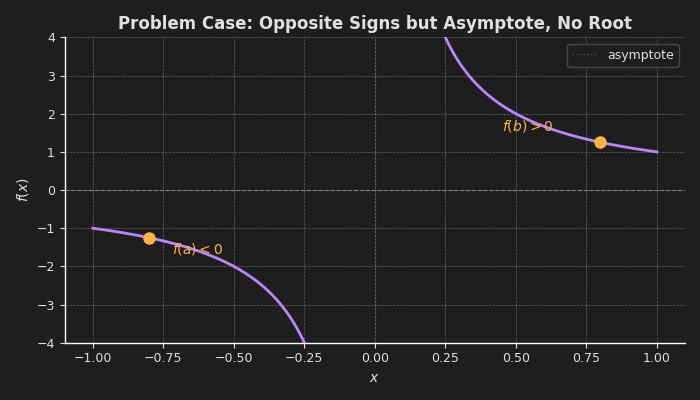

In [5]:
x1 = np.linspace(-1.0, -0.02, 400)
x2 = np.linspace(0.02, 1.0, 400)
f_asymp = lambda x: 1.0 / x

a, b = -0.8, 0.8
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x1, f_asymp(x1), color=C['purple'], lw=2)
ax.plot(x2, f_asymp(x2), color=C['purple'], lw=2)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=1, ls=':', alpha=0.5, label='asymptote')
ax.plot([a], [f_asymp(a)], 'o', color=C['orange'], ms=8)
ax.plot([b], [f_asymp(b)], 'o', color=C['orange'], ms=8)
ax.annotate('$f(a)<0$', xy=(a, f_asymp(a)), xytext=(a+0.08, f_asymp(a)-0.4),
            color=C['orange'], fontsize=10)
ax.annotate('$f(b)>0$', xy=(b, f_asymp(b)), xytext=(b-0.35, f_asymp(b)+0.3),
            color=C['orange'], fontsize=10)
ax.set_ylim(-4, 4)
ax.legend()
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Problem Case: Opposite Signs but Asymptote, No Root')
plt.tight_layout()



Convergence of the bisection algorithm can be determined by either having $|b-a|<\varepsilon$ for some small $\varepsilon$ or having $|f(b)-f(a)|<\varepsilon$. Which criterion you use will depend on the specific application and on what kinds of tolerances are required.

#### Example: Quantiles

Given a cumulative distribution function $F(x)$ and a number $p\in (0, 1)$, a quantile of $F$ is a number $x$ such that $F(x) = p$. The bisection algorithm can be used to find a quantile $x$ for a given $p$ by defining the function $g(x) = F(x) - p$ and solving for the value of $x$ that achieves $g(x) = 0$.

Another way to put this is that we are inverting the CDF to compute $x = F^{-1}(p)$. So the bisection algorithm can be used to invert functions in these situations.


In [6]:
def bisect(f, a, b, tol=1e-7, maxiter=1000):
    """Find root of f in [a, b] using the bisection algorithm."""
    if np.sign(f(a)) == np.sign(f(b)):
        raise ValueError("f(a) and f(b) must have opposite signs")
    for _ in range(maxiter):
        c = (a + b) / 2.0
        if f(c) == 0 or (b - a) / 2.0 < tol:
            return c
        if np.sign(f(c)) == np.sign(f(a)):
            a = c
        else:
            b = c
    return (a + b) / 2.0

bisect result: 1.959964
scipy  result: 1.959964


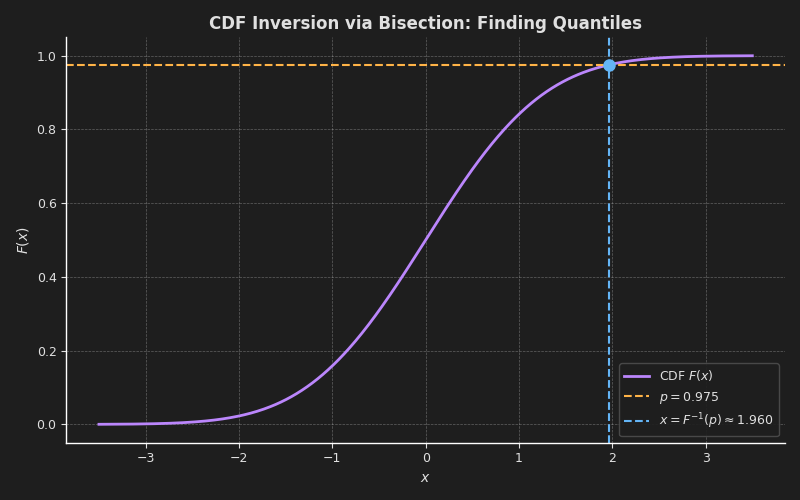

In [7]:
from scipy import stats

# Find the 97.5th percentile of N(0,1): solve F(x) - 0.975 = 0
p = 0.975
g = lambda x: stats.norm.cdf(x) - p
root = bisect(g, -10, 10)
print(f"bisect result: {root:.6f}")
print(f"scipy  result: {stats.norm.ppf(p):.6f}")

# Plot the CDF and the inversion
x = np.linspace(-3.5, 3.5, 500)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, stats.norm.cdf(x), color=C['purple'], lw=2, label='CDF $F(x)$')
ax.axhline(p, color=C['orange'], lw=1.5, ls='--', label=f'$p = {p}$')
ax.axvline(root, color=C['blue'], lw=1.5, ls='--',
           label=f'$x = F^{{-1}}(p) \\approx {root:.3f}$')
ax.plot(root, p, 'o', color=C['blue'], ms=8)
ax.set_xlabel('$x$')
ax.set_ylabel('$F(x)$')
ax.set_title('CDF Inversion via Bisection: Finding Quantiles')
ax.legend()
plt.tight_layout()